# Continuous Embeddings on MNIST

Most data is not binary. TMAP supports cosine and euclidean for dense vectors. Both go through USearch (HNSW) under the hood. This notebook walks through both metrics on MNIST so you can see what the output looks like and pick the right one for your data.

You will need scikit-learn for the MNIST download:

```
pip install scikit-learn
```


X shape: (10000, 784)
y shape: (10000,), classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


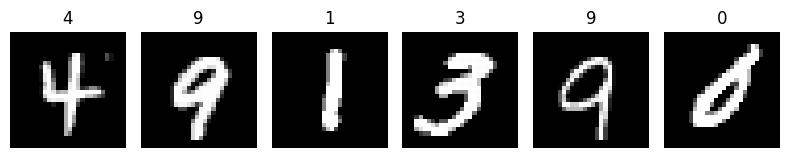

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

# fetch_openml caches into ~/scikit_learn_data on first run
mnist = fetch_openml("mnist_784", version=1, as_frame=False, cache=True)
X_full = mnist.data.astype(np.float32) / 255.0
y_full = mnist.target.astype(int)

# subsample 10k for fast cell execution
rng = np.random.default_rng(42)
idx = rng.choice(X_full.shape[0], size=10_000, replace=False)
X = X_full[idx]
y = y_full[idx]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}, classes: {sorted(set(y))}")

# show a few digits
fig, axes = plt.subplots(1, 6, figsize=(8, 1.6))
for ax, img, label in zip(axes, X[:6], y[:6]):
    ax.imshow(img.reshape(28, 28), cmap="gray")
    ax.set_title(str(label))
    ax.axis("off")
plt.tight_layout()
plt.show()


## Cosine

Use cosine when your features are learned embeddings, sentence-transformer outputs, normalized vectors, or anything where the direction of the vector matters more than its magnitude. The vector length cancels out, so two scaled copies of the same point are treated as identical.


In [2]:
from tmap import TMAP

cosine_model = TMAP(metric="cosine", n_neighbors=20, seed=42).fit(X)
print(f"embedding shape: {cosine_model.embedding_.shape}")
print(f"tree edges: {cosine_model.tree_.edges.shape[0]}")


embedding shape: (10000, 2)
tree edges: 9999


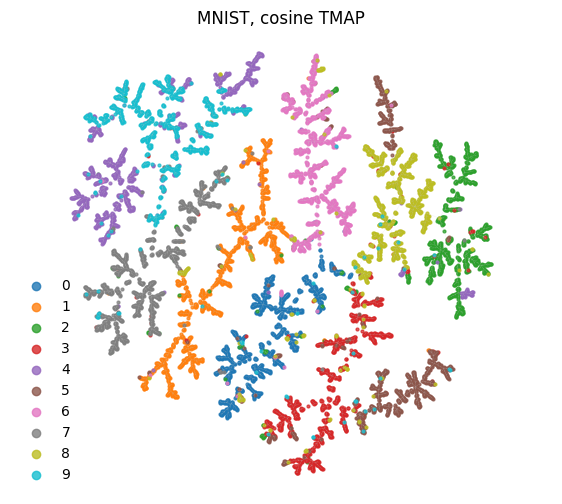

In [3]:
fig, ax = plt.subplots(figsize=(7, 6))
cosine_model.plot_static(color_by=y, color_map="tab10", point_size=4, ax=ax)
ax.set_title("MNIST, cosine TMAP")
plt.show()


## Euclidean

Use euclidean when absolute magnitude matters: raw pixel intensities, sensor readings, anything where two vectors of different lengths really are different. On MNIST, raw pixels qualify, since brighter strokes carry information about how the digit was drawn.


embedding shape: (10000, 2)
tree edges: 9999


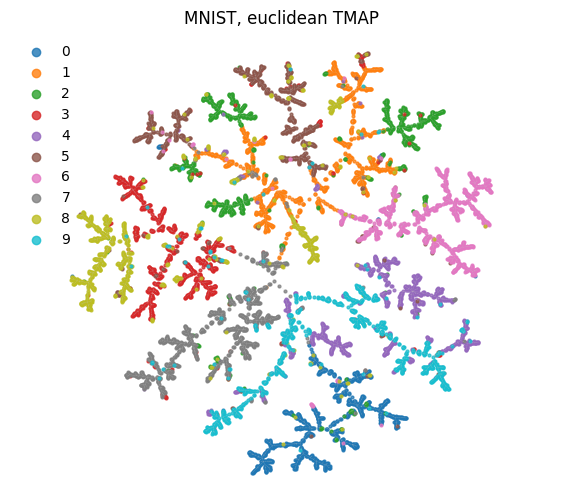

In [4]:
euclidean_model = TMAP(metric="euclidean", n_neighbors=20, seed=42).fit(X)
print(f"embedding shape: {euclidean_model.embedding_.shape}")
print(f"tree edges: {euclidean_model.tree_.edges.shape[0]}")

fig, ax = plt.subplots(figsize=(7, 6))
euclidean_model.plot_static(color_by=y, color_map="tab10", point_size=4, ax=ax)
ax.set_title("MNIST, euclidean TMAP")
plt.show()

## Comparison

Both metrics produce clear digit clusters. Cosine emphasizes shape (the direction of the pixel-intensity vector), so different stroke weights of the same digit land near each other. Euclidean emphasizes both shape and overall brightness, so lighter or thinner digits drift slightly away from heavier ones of the same class.

There is no single "better" choice. If your features are normalized embeddings, start with cosine. If raw magnitudes carry information, start with euclidean.


## What about Jaccard?

For binary fingerprints (molecular Morgan, MACCS, ECFP), use `metric="jaccard"`. The estimator auto-routes to USearch with native Jaccard distance on the bits. See `02_cheminformatics.ipynb` for a full chemistry walkthrough.

For sparse single-cell data, `metric="jaccard"` with a CSR matrix routes to MinHash and LSHForest. See `05_single_cell.ipynb` for that path.


## Next

Now that you have a fitted TMAP, head to `04_new_functionalities.ipynb` to learn how to add new points, project held-out data, measure recall, and walk paths in the tree.
